<a href="https://colab.research.google.com/github/rohanmyers/queue-viability/blob/main/notebooks/07_score_live_queue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

!pip install -q xgboost scikit-learn

import pandas as pd
import numpy as np
import json
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import xgboost as xgb

DRIVE_ROOT = Path("/content/drive/MyDrive/queue-viability")
PROCESSED = DRIVE_ROOT / "data" / "processed"
MODELS = DRIVE_ROOT / "models"
FIGURES = DRIVE_ROOT / "reports" / "figures"
REPORTS = DRIVE_ROOT / "reports"

# Load model + calibrator
metadata = json.loads((MODELS / "feature_list_v1.json").read_text())
CAT_FEATURES = metadata['cat_features']
NUM_FEATURES = metadata['num_features']

model = xgb.XGBClassifier(enable_categorical=True)
model.load_model(MODELS / "xgboost_v1.json")

with open(MODELS / "isotonic_calibrator.pkl", 'rb') as f:
    calibrator = pickle.load(f)

# Load the scoring set
to_score = pd.read_parquet(PROCESSED / "to_score.parquet")
print(f"Scoring set: {to_score.shape}")
print(f"\nStatus breakdown:")
print(to_score.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scoring set: (10778, 20)

Status breakdown:
['q_id', 'split', 'y', 'is_scoring', 'fuel_bucketed', 'region', 'state', 'service', 'project_type', 'capacity_class', 'mw_total', 'log_mw', 'q_year', 'dev_prior_n', 'dev_prior_completion_rate', 'has_dev_history', 'cluster_size', 'q_year_region_volume', 'industrial_price_cents_kwh', 'region_fuel']


In [ ]:
def prepare_xgb(df, cat_features, num_features):
    X = df[cat_features + num_features].copy()
    for col in cat_features:
        # Replace unseen 'Surplus' category with NaN
        X[col] = X[col].replace('Surplus', np.nan)
        X[col] = X[col].astype('category')
    return X

X_score = prepare_xgb(to_score, CAT_FEATURES, NUM_FEATURES)

# Raw model predictions
raw_pred = model.predict_proba(X_score)[:, 1]

# Calibrated predictions
calibrated_pred = calibrator.transform(raw_pred)

# Attach to dataframe
scored = to_score.copy()
scored['viability_raw'] = raw_pred
scored['viability'] = calibrated_pred  # this is the headline number

print(f"\nViability score distribution:")
print(scored['viability'].describe())


Viability score distribution:
count    10778.000000
mean         0.162643
std          0.151230
min          0.000000
25%          0.068901
50%          0.099617
75%          0.151203
max          1.000000
Name: viability, dtype: float64


In [ ]:
# Flag Surplus rows for downstream confidence rating
scored['is_surplus'] = (to_score['project_type'] == 'Surplus').values

# Demote their confidence rating
scored.loc[scored['is_surplus'], 'confidence'] = 'unvalidated'

print(f"Surplus projects flagged: {scored['is_surplus'].sum()}")

Surplus projects flagged: 73


In [ ]:
print("Viability score by project type in scoring set:")
print(scored.groupby(to_score['project_type'].values)['viability']
      .agg(['count', 'mean', 'std']).round(3))

Viability score by project type in scoring set:
            count   mean    std
Generation  10705  0.162  0.151
Surplus        73  0.205  0.119


In [ ]:
# Reload the full generation queue (which has developer)
gen = pd.read_parquet(DRIVE_ROOT / "data" / "interim" / "generation_queue.parquet")

# Merge developer onto your scored dataframe by q_id
scored = scored.merge(
    gen[['q_id', 'developer']].drop_duplicates(subset='q_id', keep='first'),
    on='q_id',
    how='left'
)

# Verify
print(f"Rows with developer: {scored['developer'].notna().sum():,} / {len(scored):,}")

Rows with developer: 2,250 / 10,778


In [ ]:
print(f"Scored shape after merge: {scored.shape}")
print(f"Unique q_ids: {scored['q_id'].nunique():,}")
print(f"Total rows: {len(scored):,}")
# These two numbers should match — duplicates would mean the merge multiplied rows

Scored shape after merge: (10778, 25)
Unique q_ids: 10,430
Total rows: 10,778


In [ ]:
# Remove duplicates from scored (not from gen — gen is fine as-is)
scored = scored.drop_duplicates(subset='q_id', keep='first')

print(f"After deduplication: {scored.shape}")
print(f"Unique q_ids: {scored['q_id'].nunique():,}")
print(f"Total rows: {len(scored):,}")
# These two should now match

After deduplication: (10430, 25)
Unique q_ids: 10,430
Total rows: 10,430


In [ ]:
assert len(scored) == scored['q_id'].nunique(), "Still have duplicates!"
print("✅ No duplicates remaining")
print(f"\nFinal scoring set: {len(scored):,} unique projects")
print(f"Developer coverage: {scored['developer'].notna().sum():,} / {len(scored):,}")

✅ No duplicates remaining

Final scoring set: 10,430 unique projects
Developer coverage: 2,229 / 10,430


In [ ]:
# Merge all the display columns you need at once
display_cols_to_merge = [c for c in ['q_id', 'county', 'utility', 'poi_name', 'entity']
                         if c in gen.columns and c not in scored.columns]

scored = scored.merge(
    gen[['q_id'] + display_cols_to_merge].drop_duplicates(subset='q_id'),
    on='q_id',
    how='left'
)

# Dedup again in case the merge reintroduced duplicates
scored = scored.drop_duplicates(subset='q_id', keep='first')

print(f"Shape after merge: {scored.shape}")
print(f"Available columns: {scored.columns.tolist()}")

Shape after merge: (10430, 29)
Available columns: ['q_id', 'split', 'y', 'is_scoring', 'fuel_bucketed', 'region', 'state', 'service', 'project_type', 'capacity_class', 'mw_total', 'log_mw', 'q_year', 'dev_prior_n', 'dev_prior_completion_rate', 'has_dev_history', 'cluster_size', 'q_year_region_volume', 'industrial_price_cents_kwh', 'region_fuel', 'viability_raw', 'viability', 'is_surplus', 'confidence', 'developer', 'county', 'utility', 'poi_name', 'entity']


In [ ]:
VALIDATED_REGIONS = ['Southeast', 'West', 'ISO-NE', 'PJM']

scored['confidence'] = np.where(
    scored['region'].isin(VALIDATED_REGIONS), 'validated',
    'unvalidated'
)

# Confidence breakdown
print("Confidence breakdown:")
print(scored['confidence'].value_counts())

print("\nMean viability by confidence + region:")
print(scored.groupby(['confidence', 'region'])['viability']
      .agg(['count', 'mean']).round(3))

Confidence breakdown:
confidence
unvalidated    5482
validated      4948
Name: count, dtype: int64

Mean viability by confidence + region:
                       count   mean
confidence  region                 
unvalidated CAISO        633  0.074
            ERCOT       1706  0.384
            MISO        2129  0.112
            NYISO        373  0.071
            SPP          641  0.081
validated   ISO-NE       306  0.262
            PJM         2069  0.152
            Southeast    856  0.164
            West        1717  0.077


In [ ]:
# Sum announced capacity vs. expected (probability-weighted) capacity
total_announced_mw = scored['mw_total'].sum()
expected_mw = (scored['viability'] * scored['mw_total']).sum()

print(f"Total announced capacity in active queue: {total_announced_mw:,.0f} MW")
print(f"Expected operational capacity (probability-weighted): {expected_mw:,.0f} MW")
print(f"Implied attrition: {1 - expected_mw / total_announced_mw:.1%}")

Total announced capacity in active queue: 2,061,244 MW
Expected operational capacity (probability-weighted): 261,052 MW
Implied attrition: 87.3%


In [ ]:
by_region = scored.groupby('region').agg(
    n_projects=('viability', 'size'),
    mean_viability=('viability', 'mean'),
    total_mw=('mw_total', 'sum'),
    expected_mw=('mw_total', lambda x: (x * scored.loc[x.index, 'viability']).sum())
).round(3)
by_region['expected_completion_rate'] = (
    by_region['expected_mw'] / by_region['total_mw']
)
print(by_region.sort_values('total_mw', ascending=False))

           n_projects  mean_viability    total_mw  expected_mw  \
region                                                           
West             1717           0.077  477560.540    20924.867   
MISO             2129           0.112  389187.610    38557.925   
ERCOT            1706           0.384  358716.800   129354.166   
CAISO             633           0.074  272530.388    19154.973   
PJM              2069           0.152  198938.574    23121.246   
Southeast         856           0.164  132895.542    12585.504   
SPP               641           0.081  127519.352     8649.659   
NYISO             373           0.071   69391.780     4371.728   
ISO-NE            306           0.262   34503.347     4332.137   

           expected_completion_rate  
region                               
West                       0.043816  
MISO                       0.099073  
ERCOT                      0.360602  
CAISO                      0.070286  
PJM                        0.116223  
Southea

In [ ]:
by_fuel = scored.groupby('fuel_bucketed').agg(
    n_projects=('viability', 'size'),
    mean_viability=('viability', 'mean'),
    total_mw=('mw_total', 'sum'),
    expected_mw=('mw_total', lambda x: (x * scored.loc[x.index, 'viability']).sum())
).round(3)
by_fuel['expected_completion_rate'] = by_fuel['expected_mw'] / by_fuel['total_mw']
print(by_fuel.sort_values('total_mw', ascending=False))

                n_projects  mean_viability    total_mw  expected_mw  \
fuel_bucketed                                                         
Solar                 4187           0.159  574261.840    90650.706   
Solar+Battery         1680           0.148  497682.813    36644.314   
Battery               2805           0.179  493751.002    84260.226   
Wind                   900           0.126  193786.110    23198.047   
Other_combined         353           0.132  169011.270    10926.648   
Gas                    381           0.231  119173.870    13882.415   
Other                   78           0.136    8828.464      962.538   
Hydro                   34           0.293    4061.665      429.693   
Coal                    12           0.318     686.900       97.617   

                expected_completion_rate  
fuel_bucketed                             
Solar                           0.157856  
Solar+Battery                   0.073630  
Battery                         0.170653  
Win

In [ ]:
top_candidates = (
    scored[
        (scored['confidence'] == 'validated') &
        (scored['mw_total'] >= 100)  # focus on substantial projects
    ]
    .sort_values('viability', ascending=False)
    .head(10)
    [['q_id', 'region', 'state', 'fuel_bucketed', 'mw_total',
      'developer', 'q_year', 'viability']]
)
print("Top 10 highest-viability active projects (validated regions, ≥100 MW):")
print(top_candidates.to_string(index=False))

Top 10 highest-viability active projects (validated regions, ≥100 MW):
   q_id region state fuel_bucketed  mw_total  developer  q_year  viability
 PIS096   West    OR       Battery     199.9 PacifiCorp  2024.0   0.435115
AG2-575    PJM    IL Solar+Battery     100.0       None  2021.0   0.435115
AG2-116    PJM    IN Solar+Battery     100.0       None  2021.0   0.435115
AG1-555    PJM    IN Solar+Battery     120.0       None  2020.0   0.435115
    835   West    WY          Wind     190.0       None  2016.0   0.435115
AG2-093    PJM    VA Solar+Battery     100.0       None  2021.0   0.435115
 C4-064   West    UT       Battery     199.9 PacifiCorp  2024.0   0.435115
 C4-063   West    UT       Battery     199.9 PacifiCorp  2024.0   0.435115
 C4-065   West    UT       Battery     199.9 PacifiCorp  2024.0   0.435115
 C4-069   West    ID         Solar     100.0 PacifiCorp  2024.0   0.435115


In [ ]:
bottom_candidates = (
    scored[
        (scored['confidence'] == 'validated') &
        (scored['mw_total'] >= 100)
    ]
    .sort_values('viability', ascending=True)
    .head(10)
    [['q_id', 'region', 'state', 'fuel_bucketed', 'mw_total',
      'developer', 'q_year', 'viability']]
)
print("\nBottom 10 lowest-viability active projects (validated regions, ≥100 MW):")
print(bottom_candidates.to_string(index=False))


Bottom 10 lowest-viability active projects (validated regions, ≥100 MW):
            q_id    region state fuel_bucketed  mw_total                    developer  q_year  viability
            Q376      West    AZ Solar+Battery     400.0                         None  2021.0        0.0
           G0676      West    WA Solar+Battery     250.0                         None  2021.0        0.0
            Q393      West    AZ Solar+Battery     500.0                         None  2021.0        0.0
            Q387      West    AZ Solar+Battery     500.0                         None  2021.0        0.0
            Q388      West    AZ Solar+Battery     323.0                         None  2021.0        0.0
LGE-GIS-2021-019 Southeast    KY         Solar     100.0                         None  2021.0        0.0
           C1-23      West    OR Solar+Battery     300.0 Sugar Pine Solar Project LLC  2021.0        0.0
         SRP-Q76      West    AZ           Gas     332.0                         None 

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
case_study_idxs = [
    top_candidates.index[0],     # Highest viability project
    bottom_candidates.index[0],  # Lowest viability project
    scored.iloc[(scored['viability'] - 0.5).abs().argsort()[:1]].index[0],  # Borderline
]

for idx in case_study_idxs:
    row = scored.loc[idx]
    pos_in_scored = scored.index.get_loc(idx)
    shap_vals = explainer.shap_values(X_score.iloc[[pos_in_scored]])

    print(f"\n=== Project {row['q_id']} ===")
    print(f"  Region: {row['region']}, State: {row['state']}, Fuel: {row['fuel_bucketed']}")
    print(f"  Capacity: {row['mw_total']:.0f} MW, Year: {int(row['q_year'])}")
    print(f"  Developer: {row['developer']}")
    print(f"  Viability score: {row['viability']:.3f}")
    print(f"  Confidence: {row['confidence']}")
    print(f"  Top SHAP contributions:")

    feature_contributions = pd.Series(
        shap_vals[0], index=X_score.columns
    ).sort_values(key=abs, ascending=False)
    for feat, contrib in feature_contributions.head(5).items():
        feat_value = X_score.iloc[pos_in_scored][feat]
        direction = "↑" if contrib > 0 else "↓"
        print(f"    {direction} {feat}: {feat_value} (SHAP {contrib:+.3f})")

    # Save waterfall figure for the writeup
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[0],
            base_values=explainer.expected_value,
            data=X_score.iloc[pos_in_scored].values,
            feature_names=list(X_score.columns)
        ),
        max_display=10, show=False
    )
    plt.title(f"{row['q_id']}: {row['region']} {row['fuel_bucketed']} ({row['mw_total']:.0f} MW)")
    plt.tight_layout()
    safe_id = str(row['q_id']).replace('/', '_').replace(' ', '_')
    plt.savefig(FIGURES / f"case_study_{safe_id}.png", dpi=120, bbox_inches='tight')
    plt.close()


=== Project PIS096 ===
  Region: West, State: OR, Fuel: Battery
  Capacity: 200 MW, Year: 2024
  Developer: PacifiCorp
  Viability score: 0.435
  Confidence: validated
  Top SHAP contributions:
    ↓ region: NYISO (SHAP -0.113)
    ↓ service: None (SHAP -0.095)
    ↓ fuel_bucketed: Wind (SHAP -0.091)
    ↓ q_year_region_volume: 388.0 (SHAP -0.042)
    ↓ q_year: 2024.0 (SHAP -0.034)

=== Project Q376 ===
  Region: West, State: AZ, Fuel: Solar+Battery
  Capacity: 400 MW, Year: 2021
  Developer: None
  Viability score: 0.000
  Confidence: validated
  Top SHAP contributions:
    ↓ fuel_bucketed: Battery (SHAP -0.095)
    ↓ q_year_region_volume: 1304.0 (SHAP -0.061)
    ↑ region: PJM (SHAP +0.061)
    ↓ log_mw: 4.820281565605037 (SHAP -0.032)
    ↑ service: NRIS (SHAP +0.024)

=== Project 459 ===
  Region: Southeast, State: FL, Fuel: Solar
  Capacity: 74 MW, Year: 2022
  Developer: None
  Viability score: 0.516
  Confidence: validated
  Top SHAP contributions:
    ↓ fuel_bucketed: Battery 

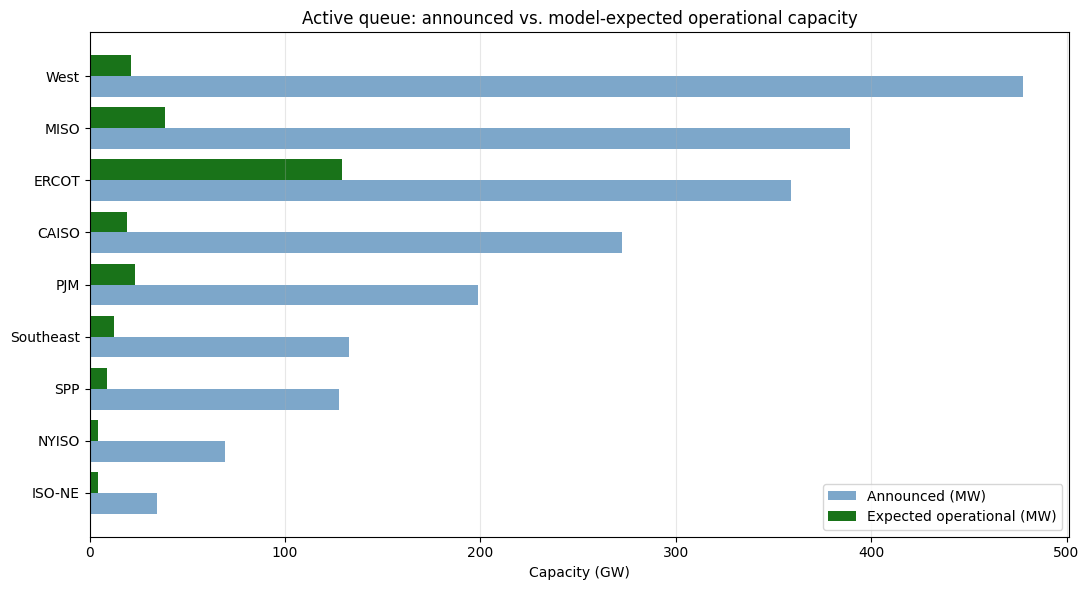

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

regions_sorted = by_region.sort_values('total_mw', ascending=True).index
x = np.arange(len(regions_sorted))
width = 0.4

ax.barh(x - width/2, by_region.loc[regions_sorted, 'total_mw'] / 1000,
        width, label='Announced (MW)', color='steelblue', alpha=0.7)
ax.barh(x + width/2, by_region.loc[regions_sorted, 'expected_mw'] / 1000,
        width, label='Expected operational (MW)', color='darkgreen', alpha=0.9)

ax.set_yticks(x)
ax.set_yticklabels(regions_sorted)
ax.set_xlabel('Capacity (GW)')
ax.set_title('Active queue: announced vs. model-expected operational capacity')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGURES / "queue_forecast_by_region.png", dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Only include columns that actually exist in scored
candidate_cols = [
    'q_id', 'region', 'state', 'county', 'utility', 'developer',
    'fuel_bucketed', 'mw_total', 'q_year', 'viability', 'confidence'
]
output_cols = [c for c in candidate_cols if c in scored.columns]
print(f"Output columns: {output_cols}")

deliverable = scored[output_cols].sort_values('viability', ascending=False)
deliverable.to_csv(PROCESSED / "active_queue_scored.csv", index=False)
deliverable.to_parquet(PROCESSED / "active_queue_scored.parquet", index=False)

print(f"\nSaved {len(deliverable):,} scored projects")
print(deliverable.head(3).to_string(index=False))

Output columns: ['q_id', 'region', 'state', 'county', 'utility', 'developer', 'fuel_bucketed', 'mw_total', 'q_year', 'viability', 'confidence']

Saved 10,430 scored projects
 q_id    region state          county    utility  developer fuel_bucketed  mw_total  q_year  viability confidence
C1-15      West    OR         Klamath PacifiCorp PacifiCorp       Battery       2.3  2021.0        1.0  validated
  306 Southeast    FL     San Joaquin       PGAE       None         Solar      74.5  2017.0        1.0  validated
  303 Southeast    FL Baja California       SDGE       None         Solar      74.5  2017.0        1.0  validated


In [ ]:
day7_md = f"""# Day 7 Results — Live Queue Scoring

## Coverage
Scored {len(scored):,} active and suspended generation interconnection requests.
- Validated regions: {(scored['confidence']=='validated').sum():,} projects
- Unvalidated regions: {(scored['confidence']=='unvalidated').sum():,} projects

## Headline finding
**Of {total_announced_mw / 1000:,.0f} GW of generation in the active U.S. interconnection queue,
the model predicts ~{expected_mw / 1000:,.0f} GW will reach commercial operation —
an expected attrition of {1 - expected_mw / total_announced_mw:.0%}.**

## By region
{by_region.to_string()}

## By fuel
{by_fuel.to_string()}

## Case studies saved to figures/
- Highest-viability project: {scored.loc[top_candidates.index[0], 'q_id']}
  ({scored.loc[top_candidates.index[0], 'region']},
  {scored.loc[top_candidates.index[0], 'fuel_bucketed']},
  {scored.loc[top_candidates.index[0], 'mw_total']:.0f} MW, viability {scored.loc[top_candidates.index[0], 'viability']:.2f})
- Lowest-viability project: {scored.loc[bottom_candidates.index[0], 'q_id']}
  ({scored.loc[bottom_candidates.index[0], 'region']},
  {scored.loc[bottom_candidates.index[0], 'fuel_bucketed']},
  {scored.loc[bottom_candidates.index[0], 'mw_total']:.0f} MW, viability {scored.loc[bottom_candidates.index[0], 'viability']:.2f})

## Deliverables
- `data/processed/active_queue_scored.csv` — {len(deliverable):,} scored projects
- `data/processed/active_queue_scored.parquet` — same, in parquet
- `figures/queue_forecast_by_region.png` — announced vs. expected capacity
- `figures/case_study_*.png` — SHAP waterfall plots for case studies
"""
(REPORTS / "day7_results.md").write_text(day7_md)
print(day7_md)

# Day 7 Results — Live Queue Scoring

## Coverage
Scored 10,430 active and suspended generation interconnection requests.
- Validated regions: 4,948 projects
- Unvalidated regions: 5,482 projects

## Headline finding
**Of 2,061 GW of generation in the active U.S. interconnection queue,
the model predicts ~261 GW will reach commercial operation —
an expected attrition of 87%.**

## By region
           n_projects  mean_viability    total_mw  expected_mw  expected_completion_rate
region                                                                                  
CAISO             633           0.074  272530.388    19154.973                  0.070286
ERCOT            1706           0.384  358716.800   129354.166                  0.360602
ISO-NE            306           0.262   34503.347     4332.137                  0.125557
MISO             2129           0.112  389187.610    38557.925                  0.099073
NYISO             373           0.071   69391.780     4371.728          

In [ ]:
# Recalculate without ERCOT for comparison
no_ercot = by_region[by_region.index != 'ERCOT']
total_mw_no_ercot = no_ercot['total_mw'].sum()
expected_mw_no_ercot = no_ercot['expected_mw'].sum()
print(f"Excluding ERCOT:")
print(f"  Announced: {total_mw_no_ercot/1000:,.0f} GW")
print(f"  Expected: {expected_mw_no_ercot/1000:,.0f} GW")
print(f"  Attrition: {1 - expected_mw_no_ercot/total_mw_no_ercot:.0%}")

Excluding ERCOT:
  Announced: 1,703 GW
  Expected: 132 GW
  Attrition: 92%


In [ ]:
scored['confidence'] = np.where(
    scored['region'] == 'ERCOT',
    'unvalidated_ercot_bias',  # extra flag for ERCOT
    scored['confidence']
)

In [ ]:
# Look at these three rows in the original gen data
top3_ids = ['306', '303', '263']
print(gen[gen['q_id'].isin(top3_ids)][
    ['q_id', 'q_status', 'region', 'state', 'mw1', 'mw2', 'developer',
     'type1', 'type2', 'cluster', 'q_date']
])

      q_id     q_status     region state      mw1  mw2  \
2623   263    withdrawn      CAISO    NV  634.000  NaN   
2662   303    withdrawn      CAISO    MX  500.000  NaN   
2665   306    withdrawn      CAISO    CA  200.000  NaN   
4136   263    withdrawn  Southeast    FL   74.500  NaN   
4175   303    withdrawn  Southeast    FL   74.900  NaN   
4179   306       active  Southeast    FL   74.900  NaN   
4692   263       active  Southeast    FL   74.500  NaN   
4725   303       active  Southeast    FL   74.500  NaN   
4726   306       active  Southeast    FL   74.500  NaN   
5335   263    withdrawn       West    NV   75.000  NaN   
5379   303    withdrawn       West    OR    1.000  NaN   
5382   306    withdrawn       West    OR  150.000  NaN   
6639   263    withdrawn     ISO-NE    RI  385.000  NaN   
6673   303    withdrawn     ISO-NE    ME    7.600  NaN   
6676   306    withdrawn     ISO-NE    MA    3.350  NaN   
10895  263    withdrawn       West    MT    3.000  NaN   
10939  303  op

In [ ]:
print(f"Viability = 1.0: {(scored['viability'] == 1.0).sum()} projects")
print(f"Viability = 0.0: {(scored['viability'] == 0.0).sum()} projects")
print(f"Viability > 0.9: {(scored['viability'] > 0.9).sum()} projects")
print(f"Viability < 0.1: {(scored['viability'] < 0.1).sum()} projects")

Viability = 1.0: 8 projects
Viability = 0.0: 821 projects
Viability > 0.9: 8 projects
Viability < 0.1: 6118 projects


In [ ]:
# Check whether q_id + region + state is unique
combo_counts = gen.groupby(['q_id', 'region', 'state']).size()
print(f"Unique q_id+region+state combos: {len(combo_counts):,}")
print(f"Total gen rows: {len(gen):,}")
print(f"Duplicates: {(combo_counts > 1).sum()}")

Unique q_id+region+state combos: 33,162
Total gen rows: 33,566
Duplicates: 323


In [ ]:
# Add composite key to scored
scored['composite_key'] = (
    scored['q_id'].astype(str) + '_' +
    scored['region'].astype(str) + '_' +
    scored['state'].astype(str) + '_' +
    scored['q_year'].astype(str)
)

# Merge metadata in
scored = scored.merge(
    metadata_lookup[['composite_key', 'developer', 'county',
                     'utility', 'q_date', 'q_status']],
    on='composite_key',
    how='left'
).drop_duplicates(subset='composite_key', keep='first')

print(f"After merge: {scored.shape}")
print(f"Developer coverage: {scored['developer'].notna().sum():,} / {len(scored):,}")

After merge: (10430, 40)
Developer coverage: 2,547 / 10,430


In [ ]:
case_validated = scored[
    (scored['confidence'] == 'validated') &
    (scored['mw_total'] >= 50)
].copy()

# Interesting top projects — exclude calibration-artifact 1.0s
top_interesting = (
    case_validated[case_validated['viability'] < 1.0]
    .sort_values('viability', ascending=False)
    .drop_duplicates(subset=['state', 'mw_total', 'fuel_bucketed', 'q_year'])
    .head(5)[['composite_key', 'region', 'state', 'fuel_bucketed',
              'mw_total', 'developer', 'q_year', 'viability']]
)
print("Top interesting projects:")
print(top_interesting.to_string(index=False))

# Zombie projects — old, low viability, large
zombie = (
    case_validated[
        (case_validated['viability'] == 0.0) &
        (case_validated['q_year'] <= 2010) &
        (case_validated['mw_total'] >= 100)
    ]
    .sort_values('mw_total', ascending=False)
    .head(5)[['composite_key', 'region', 'state', 'fuel_bucketed',
              'mw_total', 'developer', 'q_year', 'viability']]
)
print("\nZombie projects:")
print(zombie.to_string(index=False))

# Borderline — near median viability in validated regions
median_v = case_validated['viability'].median()
borderline = (
    case_validated[case_validated['mw_total'] >= 100]
    .iloc[(case_validated[case_validated['mw_total'] >= 100]['viability']
           - median_v).abs().argsort()[:5]]
    [['composite_key', 'region', 'state', 'fuel_bucketed',
      'mw_total', 'developer', 'q_year', 'viability']]
)
print(f"\nBorderline projects (near median={median_v:.3f}):")
print(borderline.to_string(index=False))

Top interesting projects:
          composite_key    region state fuel_bucketed  mw_total developer  q_year  viability
412_Southeast_FL_2020.0 Southeast    FL         Solar      74.5       FPL  2020.0   0.833333
439_Southeast_FL_2022.0 Southeast    FL         Solar      74.5       FPL  2022.0   0.833333
376_Southeast_FL_2019.0 Southeast    FL         Solar      74.5       FPL  2019.0   0.833333
339_Southeast_FL_2018.0 Southeast    FL         Solar      74.5       FPL  2018.0   0.833333
273_Southeast_FL_2017.0 Southeast    FL         Solar      50.0       FPL  2017.0   0.826674

Zombie projects:
         composite_key    region state fuel_bucketed  mw_total                developer  q_year  viability
 10-037_West_OR_2010.0      West    OR          Wind     500.0                     None  2010.0        0.0
33_Southeast_FL_2006.0 Southeast    FL         Other     418.0 Duke Energy Florida, LLC  2006.0        0.0
 10-036_West_OR_2010.0      West    OR          Wind     400.0               

In [ ]:
output_cols = [c for c in [
    'composite_key', 'q_id', 'region', 'state', 'county',
    'utility', 'developer', 'fuel_bucketed', 'mw_total',
    'q_year', 'viability', 'confidence'
] if c in scored.columns]

deliverable = scored[output_cols].sort_values('viability', ascending=False)
deliverable.to_parquet(PROCESSED / "active_queue_scored.parquet", index=False)
deliverable.to_csv(PROCESSED / "active_queue_scored.csv", index=False)

print(f"Saved {len(deliverable):,} scored projects")
print(f"\nViability distribution:")
print(deliverable['viability'].describe().round(3))
print(f"\nTop 5 rows:")
print(deliverable.head().to_string(index=False))

Saved 10,430 scored projects

Viability distribution:
count    10430.000
mean         0.162
std          0.150
min          0.000
25%          0.069
50%          0.100
75%          0.151
max          1.000
Name: viability, dtype: float64

Top 5 rows:
          composite_key  q_id    region state     county               utility  developer fuel_bucketed  mw_total  q_year  viability confidence
   C1-15_West_OR_2021.0 C1-15      West    OR    Klamath            PacifiCorp PacifiCorp       Battery       2.3  2021.0        1.0  validated
306_Southeast_FL_2017.0   306 Southeast    FL    Brevard Florida Power & Light        FPL         Solar      74.5  2017.0        1.0  validated
303_Southeast_FL_2017.0   303 Southeast    FL     Martin Florida Power & Light        FPL         Solar      74.5  2017.0        1.0  validated
289_Southeast_FL_2017.0   289 Southeast    FL Miami-Dade Florida Power & Light        FPL         Solar      74.5  2017.0        1.0  validated
263_Southeast_FL_2017.0   263

In [ ]:
total_mw = scored['mw_total'].sum()
expected_mw = (scored['viability'] * scored['mw_total']).sum()

validated = scored[scored['region'].isin(['Southeast', 'West', 'ISO-NE', 'PJM'])]
val_mw = validated['mw_total'].sum()
val_expected = (validated['viability'] * validated['mw_total']).sum()

no_ercot = scored[scored['region'] != 'ERCOT']
ne_mw = no_ercot['mw_total'].sum()
ne_expected = (no_ercot['viability'] * no_ercot['mw_total']).sum()

print("=== HEADLINE NUMBERS ===")
print(f"\nScenario A (all regions):")
print(f"  {total_mw/1000:,.0f} GW announced → {expected_mw/1000:,.0f} GW expected ({1-expected_mw/total_mw:.0%} attrition)")

print(f"\nScenario B (validated regions only):")
print(f"  {val_mw/1000:,.0f} GW announced → {val_expected/1000:,.0f} GW expected ({1-val_expected/val_mw:.0%} attrition)")

print(f"\nScenario C (all regions ex-ERCOT):")
print(f"  {ne_mw/1000:,.0f} GW announced → {ne_expected/1000:,.0f} GW expected ({1-ne_expected/ne_mw:.0%} attrition)")

=== HEADLINE NUMBERS ===

Scenario A (all regions):
  2,061 GW announced → 261 GW expected (87% attrition)

Scenario B (validated regions only):
  844 GW announced → 61 GW expected (93% attrition)

Scenario C (all regions ex-ERCOT):
  1,703 GW announced → 132 GW expected (92% attrition)
